In [2]:
import numpy as np
import pandas as pd
import multiprocessing as mp
from inspect import signature
from matplotlib import pyplot as plt
from dacbench.logger import Logger, log2dataframe, load_logs
import seaborn as sns
import glob
from plotting import plot_performance_over_time, plot_final_performance_comparison, plot_improvement_probability, plot_configuration_footprint, plot_hp_importance, plot_deepcave

/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/envs/__init__.py:35: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028


DACBench Gym registration failed - make sure you have all dependencies installed and their instance sets in the right path!


/home/micha/anaconda3/envs/PFDAC/lib/python3.10/site-packages/dacbench/benchmarks/__init__.py:26: UserWarning: CMA-ES Benchmark not installed. If you want to use this benchmark, please follow the installation guide.
  warnings.warn(  # noqa: B028


In [15]:
def toDataFrame(glob_path, col_name, col_index, method):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d])

    df['method'] = method

    return df

def toChunkedDataFrame(glob_path, col_name, col_index, chunk_size):
    d =  [log2dataframe(load_logs(path)) for path in glob.glob(glob_path)]

    df = pd.DataFrame([s[col_name][col_index] for s in d]).transpose()

    result_df = pd.DataFrame()
    for col in df.columns:
        reshaped_data = df[col].values.reshape(-1, chunk_size)
        result_df[col] = reshaped_data.mean(axis=1)

    result_df.reset_index()

    result_df['epoch'] = result_df.index + 1
    result_df = result_df.melt(id_vars=['epoch'])

    return result_df

sns.set_style('whitegrid')

<Axes: xlabel='method', ylabel='0'>

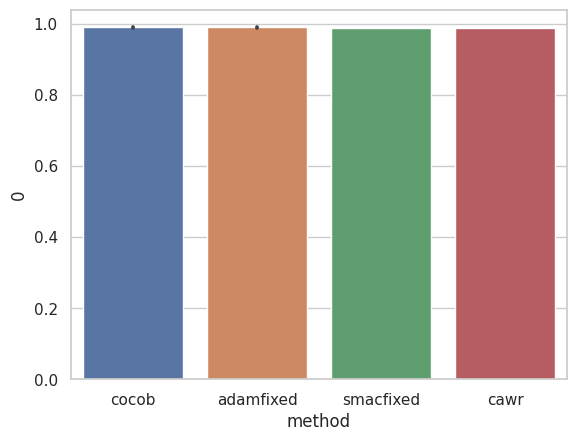

In [34]:
cocob_ta_mnist = toDataFrame('./results_cluster/results/COCOB_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_mnist = toDataFrame('./results_cluster/results/Adam_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_mnist = toDataFrame('./results_cluster/results/SMAC_fixed_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
cawr_ta_mnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([cocob_ta_mnist, adamfixed_ta_mnist, smacfixed_ta_mnist, cawr_ta_mnist])
sns.barplot(data=data, x='method', y=0)

<Axes: xlabel='method', ylabel='0'>

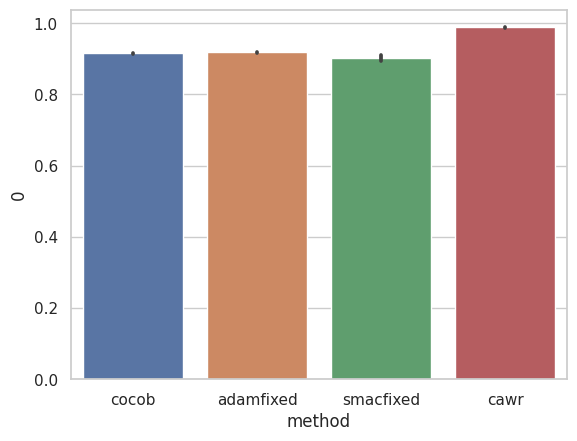

In [35]:
cocob_ta_fmnist = toDataFrame('./results_cluster/results/COCOB_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_fmnist = toDataFrame('./results_cluster/results/Adam_fixed_fmnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_fmnist = toDataFrame('./results_cluster/results/SMAC_fixed_fashion_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
cawr_ta_fmnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([cocob_ta_fmnist, adamfixed_ta_fmnist, smacfixed_ta_fmnist, cawr_ta_fmnist])
sns.barplot(data=data, x='method', y=0)

<Axes: xlabel='method', ylabel='0'>

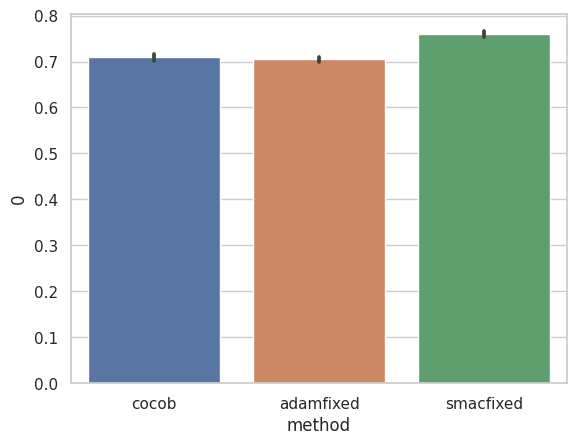

In [37]:
cocob_ta_cifar10 = toDataFrame('./results_cluster/results/COCOB_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cocob')
adamfixed_ta_cifar10 = toDataFrame('./results_cluster/results/Adam_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'adamfixed')
smacfixed_ta_cifar10 = toDataFrame('./results_cluster/results/SMAC_fixed_cifar10/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'smacfixed')
#cawr_ta_mnist = toDataFrame('./results_cluster/results/CAWR_mnist/*/CustomTrackingWrapper.jsonl', 'test_accuracy', 8, 'cawr')
data = pd.concat([cocob_ta_cifar10, adamfixed_ta_cifar10, smacfixed_ta_cifar10])
sns.barplot(data=data, x='method', y=0)

Text(0, 0.5, 'Validation Accuracy')

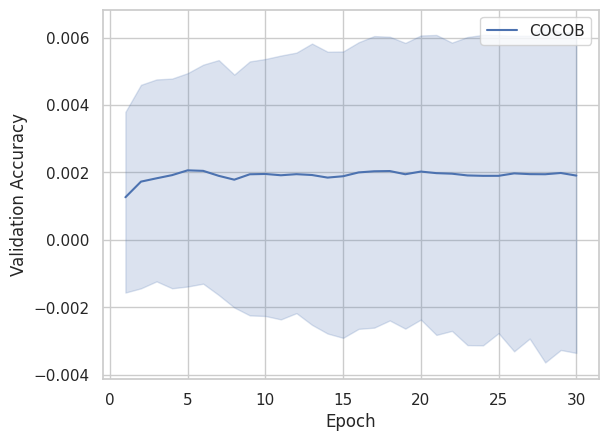

In [10]:

cocob_elr = toDataFrame('./results_cluster/results/COCOB_mnist/*/CustomTrackingWrapper.jsonl', 'effective_lrs', 9)
sns.lineplot(data=cocob_elr, x='epoch', y='value', label='COCOB')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')